In [2]:
import h5py
import ROOT

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

Welcome to JupyROOT 6.26/16


In [ ]:
# This function ensures that `event_id` is monotonically increasing with the vertex number
def check_vertices_well_formed(f):
    print("Checking that vertices are well formed...")
    event_id = f['vertices'][0]['event_id']
    
    for vertex in f['vertices']:
        if vertex['event_id'] < event_id:
            print("Bad vertex: vertex #" + str(vertex['file_vertex_id']) + " is misplaced!")
        event_id = vertex['event_id']

    print("Done!\n")

# This function ensures that each event has exactly one vertex (test requires that vertices are well formed)
def check_vertices(f):
    print("Checking vertices...")
    event_id = f['vertices'][0]['event_id']
    
    for vertex in f['vertices']:
        if vertex['vertex_id'] != 0:
            print("Bad vertex: vertex #" + str(vertex['file_vertex_id']) + " has vertex ID " + str(vertex['vertex_id']) + " (event ID: " + str(vertex['event_id']) + ")!")
        
        while vertex['event_id'] > (event_id + 1):
            print("Bad event: event #" + str(event_id + 1) + " has no associated vertex!")
            event_id += 1

        event_id = vertex['event_id']
    
    print("Done!\n")

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')
check_vertices(f)

In [ ]:
# This function ensures that each hit segment has only one contributing trajectory
def check_segment_trajectories(f):
    print("Checking that each segment has exactly one contributing trajectory...")
    events = f.Get("EDepSimEvents")
    event = ROOT.TG4Event()
    events.SetBranchAddress("Event",ROOT.AddressOf(event))

    for i in range(f['vertices'][0]['event_id'], f['vertices'][0]['event_id'] + len(f['vertices'])):
        events.GetEntry(i)
    
        for containerName, hitSegments in event.SegmentDetectors:
            for iHit, hitSegment in enumerate(hitSegments):
                if hitSegment.Contrib.size() != 1:                        
                    print("Segment #" + str(iHit) + " (event #" + str(i) + ") has " + str(hitSegment.Contrib.size()) + " contributing trajectories!")
                    
    print("Done!\n")

f = ROOT.TFile.Open("/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.root")
check_segment_trajectories(f)

In [ ]:
# This function ensures that `event_id` is monotonically increasing with trajectory number
def check_trajectories_well_formed(f):
    print("Checking that trajectories are well formed...")
    event_id = f['trajectories'][0]['event_id']

    for traj in f['trajectories']:
        if traj['event_id'] < event_id:
            print("Bad trajectory: trajectory #" + str(traj['file_traj_id']) + " is misplaced!")
        event_id = traj['event_id']

    print("Done!\n")

# This function ensures that all events have no duplicate trajectories and all trajectories are present (i.e., trajectories with IDs 0 to (n-1), where n is the number of trajectories for that event)
def check_trajectories(f):
    print("Checking trajectories...")
    event_id = f['trajectories'][0]['event_id']
    traj_ids = []
    
    for traj in f['trajectories']:
        if traj['event_id'] > event_id:
            for i in range(len(traj_ids)):
                if i not in traj_ids:               
                    print("Bad event: event #" + str(event_id) + " has no trajectory #" + str(i) + "!")
                    
            event_id = traj['event_id']
            traj_ids = []

        if traj['traj_id'] in traj_ids:
            print("Bad trajectory: trajectory #" + str(traj['file_traj_id']) + " with trajectory ID " + str(traj['traj_id']) + " is a duplicate (event ID: " + str(traj['event_id']) + ")!")
        
        traj_ids.append(traj['traj_id'])

    print("Done!\n")
    
f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')
check_trajectories(f)

In [ ]:
def in_active_volume(xyz_start, xyz_end):
    return max(abs(xyz_start[0]), abs(xyz_start[2]), abs(xyz_end[0]), abs(xyz_end[2])) <= 30 and max(abs(xyz_start[1]), abs(xyz_end[1])) <= 25

# This function ensures that `event_id` is monotonically increasing with segment number
def check_segments_well_formed(f):
    print("Checking that segments are well formed...")
    event_id = f['segments'][0]['event_id']

    for seg in f['segments']:
        if seg['event_id'] < event_id:
            print("Bad segment: segment #" + str(seg['segment_id']) + " is misplaced!")
        event_id = seg['event_id']

    print("Done!\n")

# This function ensures that the energy deposition of each segment sums to the total energy of the trajectory
def check_segments(f):
    print("Checking segments...")
    
    event_id = f['segments'][0]['event_id']
    energies = {}
    for seg in f['segments']:
        if seg['event_id'] > event_id:
            for file_traj_id in energies:
                traj = next((x for x in f['trajectories'][max(int(file_traj_id) - 100, 0) : min(int(file_traj_id) + 100, len(f['trajectories']) - 1)] if x['file_traj_id'] == file_traj_id), None)
                if abs(energies[file_traj_id] - (traj['E_start'] - traj['E_end'])) >= 0.0001 and in_active_volume(traj['xyz_start'], traj['xyz_end']):
                    print("Bad trajectory: segment energies corresponding to trajectory #" + str(file_traj_id) + " (traj_id: " + str(traj['traj_id']) + ", event_id: " + str(traj['event_id']) + ") do not match! The sum of the segment energies is " + str(energies[file_traj_id]) + ", while the difference in trajectory energies is " + str(traj['E_start'] - traj['E_end']) + "!")
            energies = {}
            
        event_id = seg['event_id']

        if energies.get(seg['file_traj_id']):
            energies[seg['file_traj_id']] += seg['dE']
        else:
            energies[seg['file_traj_id']] = seg['dE']

    print("Done!\n")
            
f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')
check_segments(f)

In [ ]:
# This function checks for duplicate primary electrons
def check_for_duplicate_primary_electrons(f):
    print("Checking for duplicate primary electrons...")

    event_id = f['trajectories'][0]['event_id']
    hit = False
    
    for traj in f['trajectories']:
        if traj['event_id'] > event_id:
            if not hit:
                print("Bad event: event #" + str(event_id) + " has no primary electrons!")
            
            hit = False
            event_id = traj['event_id']
            
        if traj['parent_id'] == -1 and traj['pdg_id'] == 11:
            if hit:
                print("Bad event: event #" + str(event_id) + " has at least primary electrons!")
            else:
                hit = True

    print("Done!\n")

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')
check_for_duplicate_primary_electrons(f)

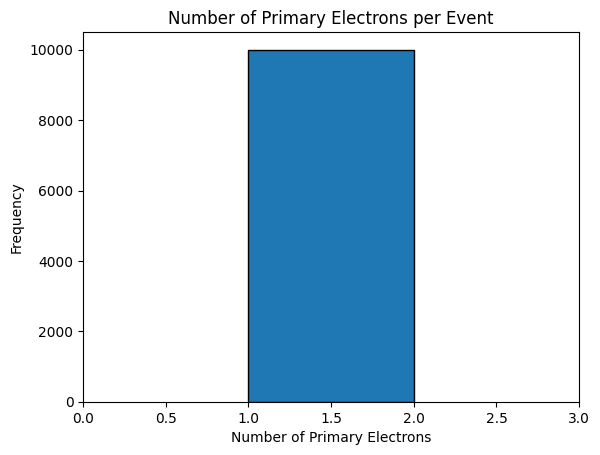

In [71]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary electron multiplicity plot
data = []

event_id = f['trajectories'][0]['event_id']
n_pelec = 0

for traj in f['trajectories']:  
    if traj['event_id'] > event_id:
        data.append(n_pelec)
        event_id = traj['event_id']
        n_pelec = 0

    if traj['parent_id'] == -1 and traj['pdg_id'] == 11:
        n_pelec += 1

# Define bins
bins = np.arange(1, 3, 1)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(0, 3)

# Axis labels
plt.xlabel('Number of Primary Electrons')
plt.ylabel('Frequency')
plt.title('Number of Primary Electrons per Event')

plt.show()

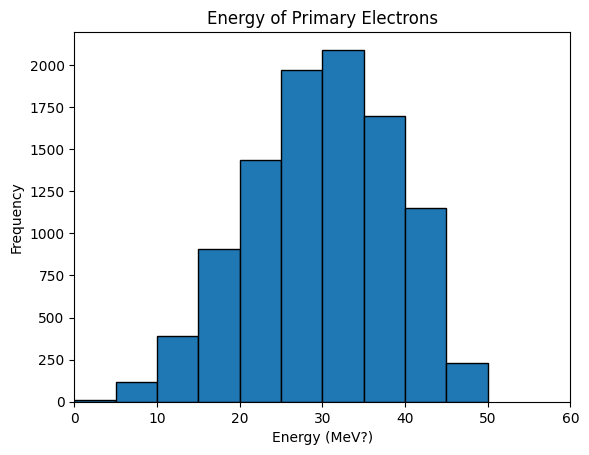

In [72]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary electron energy plot
data = []

for traj in f['trajectories']:  
    if traj['parent_id'] == -1 and traj['pdg_id'] == 11:
        data.append(traj['E_start'])

# Define bins
bins = np.arange(0, 55, 5)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(0, 60)

# Axis labels
plt.xlabel('Energy (MeV?)')
plt.ylabel('Frequency')
plt.title('Energy of Primary Electrons')

plt.show()

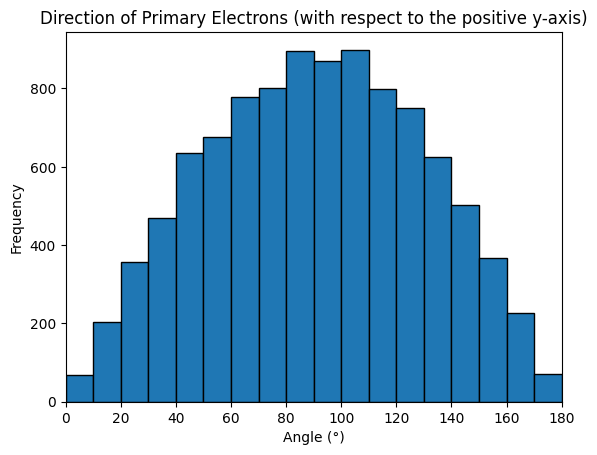

In [74]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary electron direction plot
data = []

for traj in f['trajectories']:
    if traj['parent_id'] == -1 and traj['pdg_id'] == 11:
        data.append(np.degrees(np.arccos(traj['pxyz_start'][1] / np.sqrt(np.sum(np.square(traj['pxyz_start']))))))

# Define bins
bins = np.arange(0, 190, 10)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(0, 180)

# Axis labels
plt.xlabel('Angle (°)')
plt.ylabel('Frequency')
plt.title('Direction of Primary Electrons (with respect to the positive y-axis)')

plt.show()

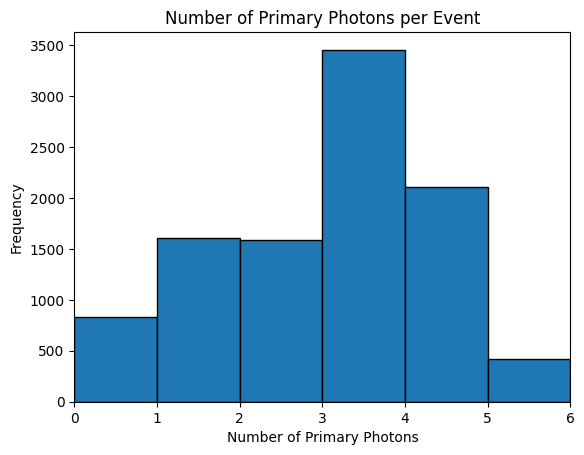

In [76]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary photon multiplicity plot
data = []

event_id = f['trajectories'][0]['event_id']
n_ppho = 0

for traj in f['trajectories']:  
    if traj['event_id'] > event_id:
        data.append(n_ppho)
        event_id = traj['event_id']
        n_ppho = 0

    if traj['parent_id'] == -1 and traj['pdg_id'] == 22:
        n_ppho += 1

# Define bins
bins = np.arange(0, 7, 1)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(0, 6)

# Axis labels
plt.xlabel('Number of Primary Photons')
plt.ylabel('Frequency')
plt.title('Number of Primary Photons per Event')

plt.show()

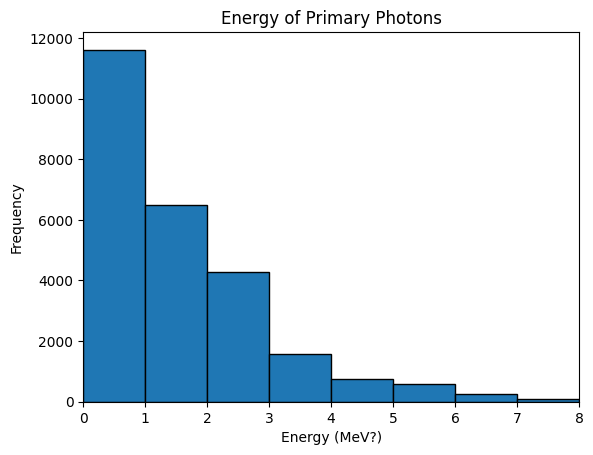

In [78]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary photon energy plot
data = []

for traj in f['trajectories']:  
    if traj['parent_id'] == -1 and traj['pdg_id'] == 22:
        data.append(traj['E_start'])

# Define bins
bins = np.arange(0, 9, 1)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(0, 8)

# Axis labels
plt.xlabel('Energy (MeV?)')
plt.ylabel('Frequency')
plt.title('Energy of Primary Photons')

plt.show()

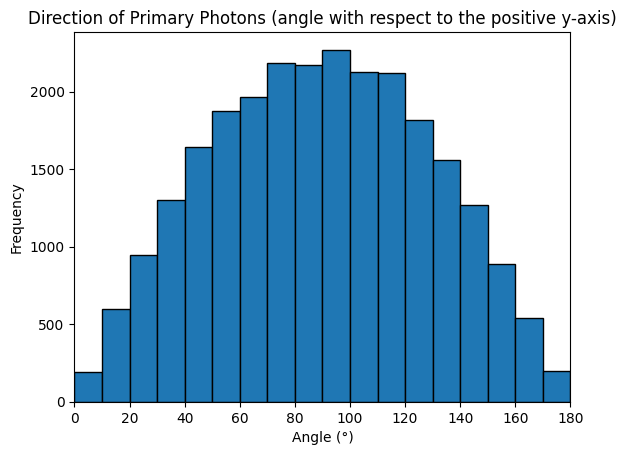

In [80]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary photon direction plot
data = []

for traj in f['trajectories']:
    if traj['parent_id'] == -1 and traj['pdg_id'] == 22:
        data.append(np.degrees(np.arccos(traj['pxyz_start'][1] / np.sqrt(np.sum(np.square(traj['pxyz_start']))))))

# Define bins
bins = np.arange(0, 190, 10)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(0, 180)

# Axis labels
plt.xlabel('Angle (°)')
plt.ylabel('Frequency')
plt.title('Direction of Primary Photons (with respect to the positive y-axis)')

plt.show()

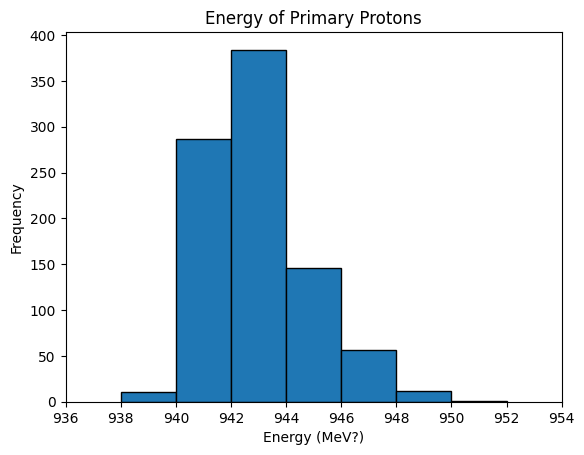

In [6]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary proton energy plot
data = []

for traj in f['trajectories']:  
    if traj['parent_id'] == -1 and traj['pdg_id'] == 2212:
        data.append(traj['E_start'])

# Define bins
bins = np.arange(938, 954, 2)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(936, 954)

# Axis labels
plt.xlabel('Energy (MeV?)')
plt.ylabel('Frequency')
plt.title('Energy of Primary Protons')

plt.show()

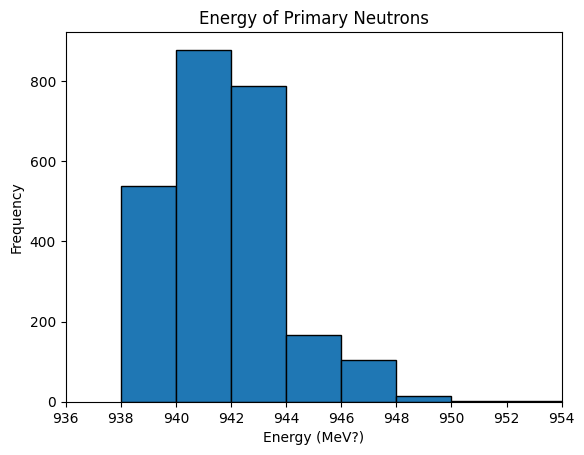

In [9]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary neutron energy plot
data = []

for traj in f['trajectories']:  
    if traj['parent_id'] == -1 and traj['pdg_id'] == 2112:
        data.append(traj['E_start'])

# Define bins
bins = np.arange(938, 956, 2)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(936, 954)

# Axis labels
plt.xlabel('Energy (MeV?)')
plt.ylabel('Frequency')
plt.title('Energy of Primary Neutrons')

plt.show()

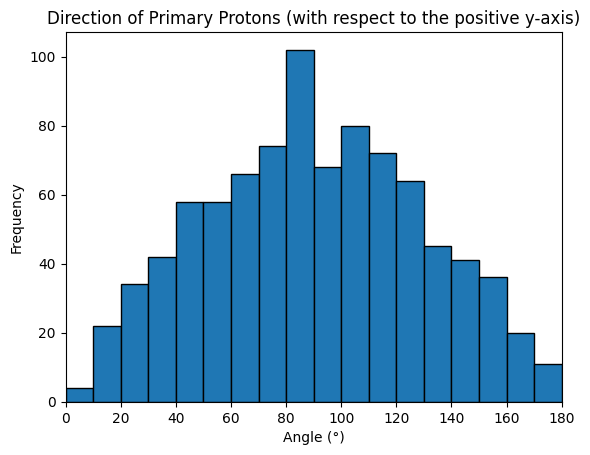

In [10]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary proton direction plot
data = []

for traj in f['trajectories']:
    if traj['parent_id'] == -1 and traj['pdg_id'] == 2212:
        data.append(np.degrees(np.arccos(traj['pxyz_start'][1] / np.sqrt(np.sum(np.square(traj['pxyz_start']))))))

# Define bins
bins = np.arange(0, 190, 10)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(0, 180)

# Axis labels
plt.xlabel('Angle (°)')
plt.ylabel('Frequency')
plt.title('Direction of Primary Protons (with respect to the positive y-axis)')

plt.show()

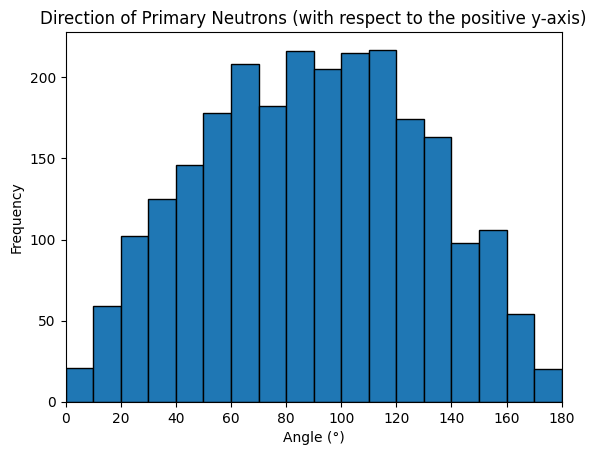

In [11]:
import matplotlib.pyplot as plt
import numpy as np

f = h5py.File('/sdf/data/neutrino/yuntse/coherent/SNeNDSens/g4/NueArCC/nueArCC_sns_yDir_g4_0000.h5', 'r')

# Primary neutron direction plot
data = []

for traj in f['trajectories']:
    if traj['parent_id'] == -1 and traj['pdg_id'] == 2112:
        data.append(np.degrees(np.arccos(traj['pxyz_start'][1] / np.sqrt(np.sum(np.square(traj['pxyz_start']))))))

# Define bins
bins = np.arange(0, 190, 10)
plt.hist(data, bins=bins, edgecolor='black')
plt.xlim(0, 180)

# Axis labels
plt.xlabel('Angle (°)')
plt.ylabel('Frequency')
plt.title('Direction of Primary Neutrons (with respect to the positive y-axis)')

plt.show()